In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")


In [3]:
housing_dataset = pd.read_csv('Housing.csv')
df = housing_dataset.copy()
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


***Visualizing Numerical Features***

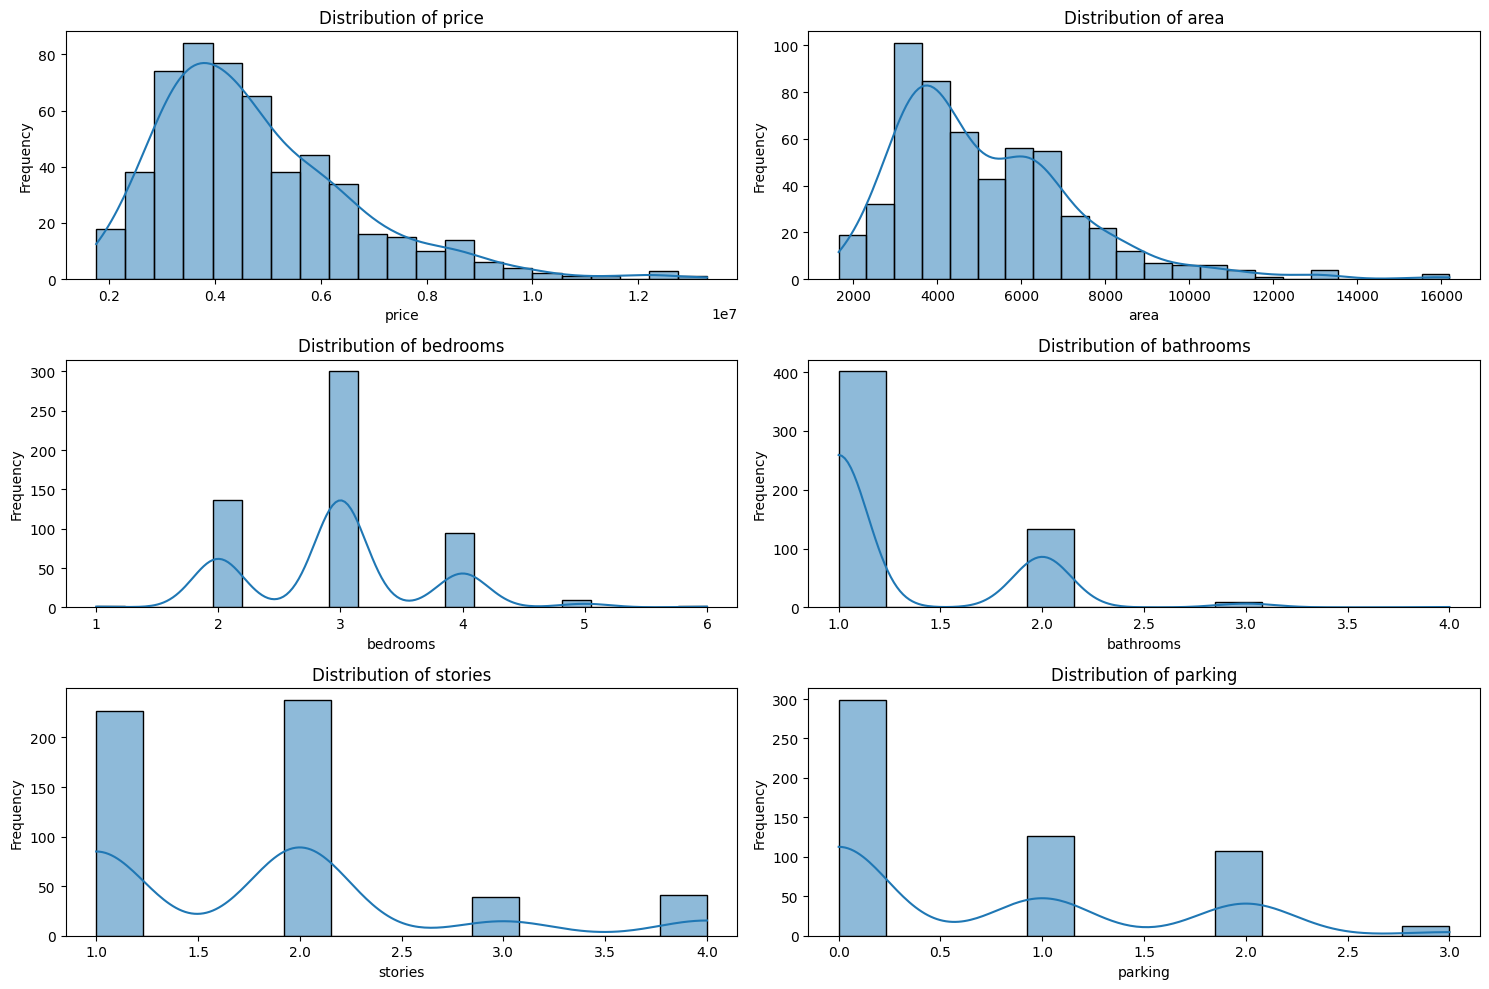

In [ ]:
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1) # 3 rows, 2 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

***Visualizing Categorical Features***

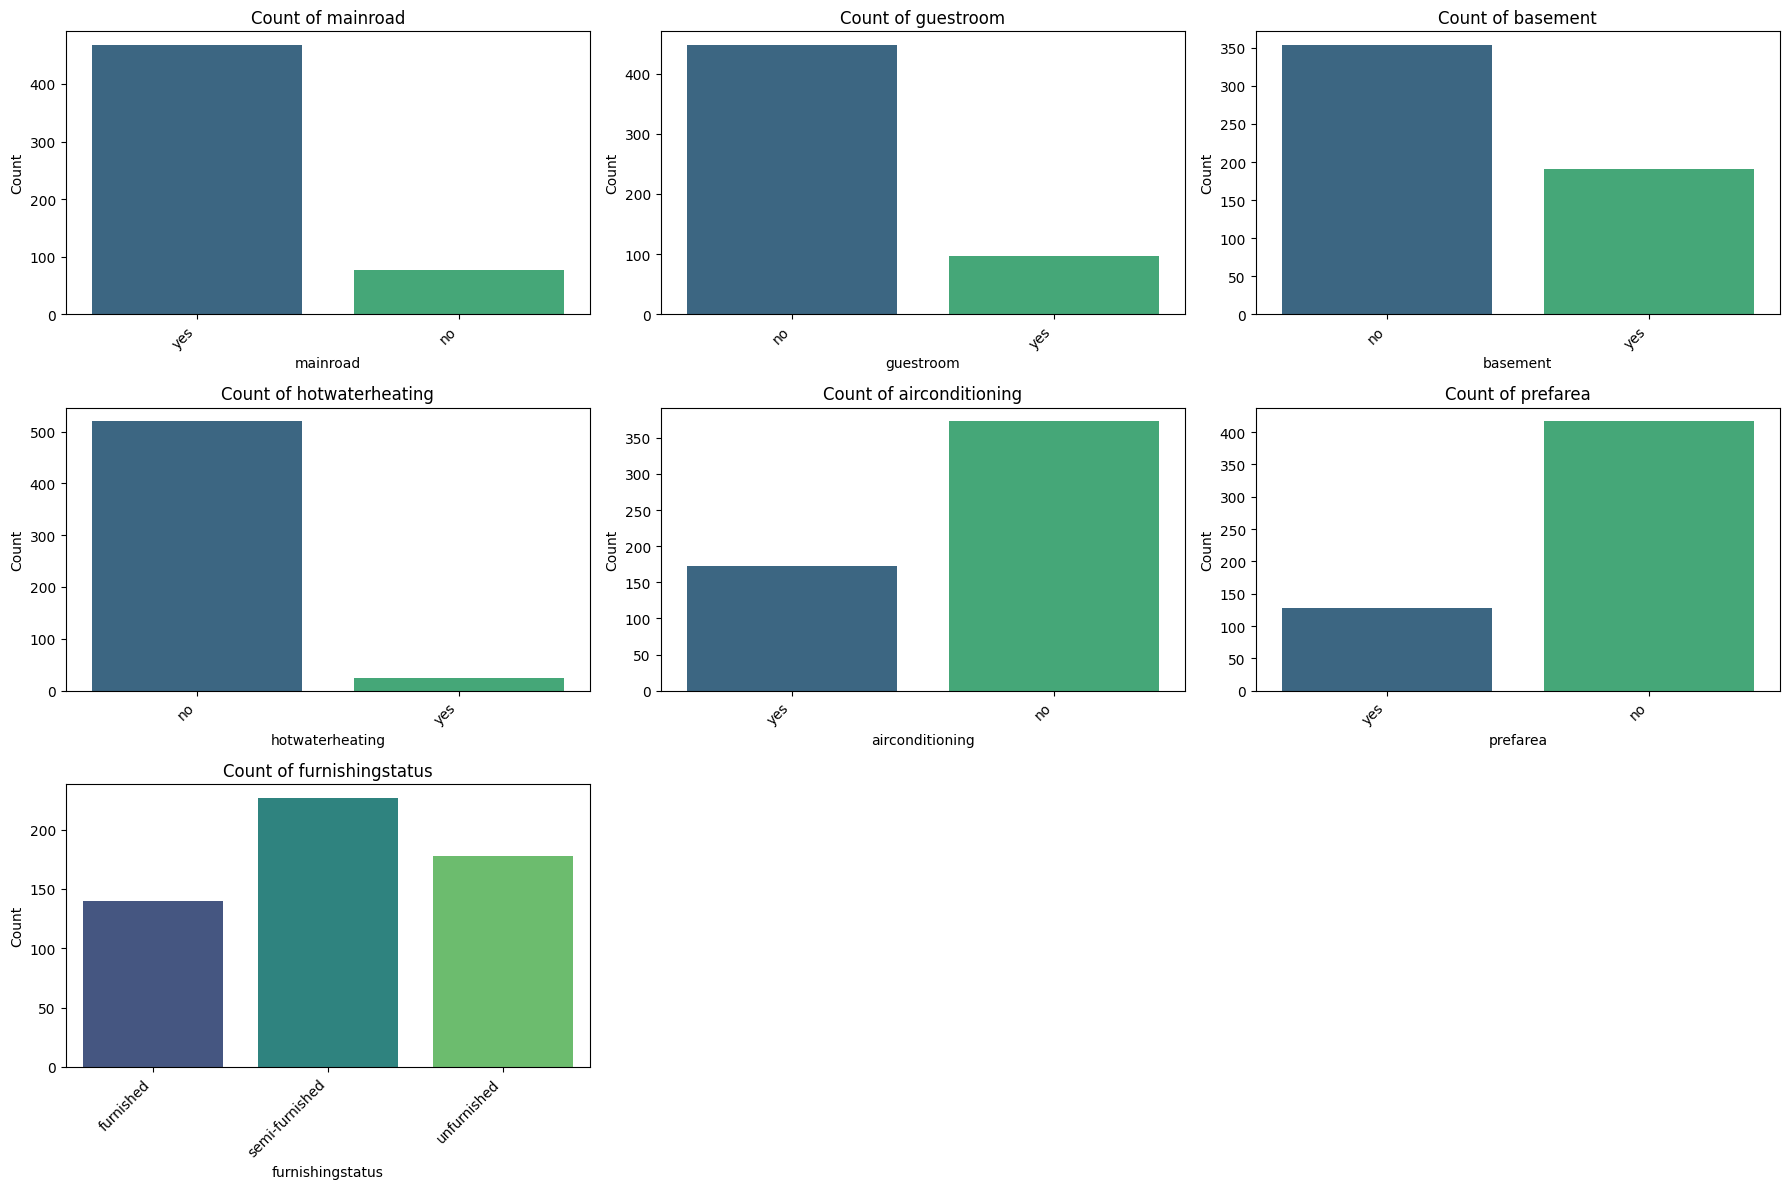

In [ ]:
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

## Bivariate Analysis

### Numerical vs. Numerical Features (Price vs. others)

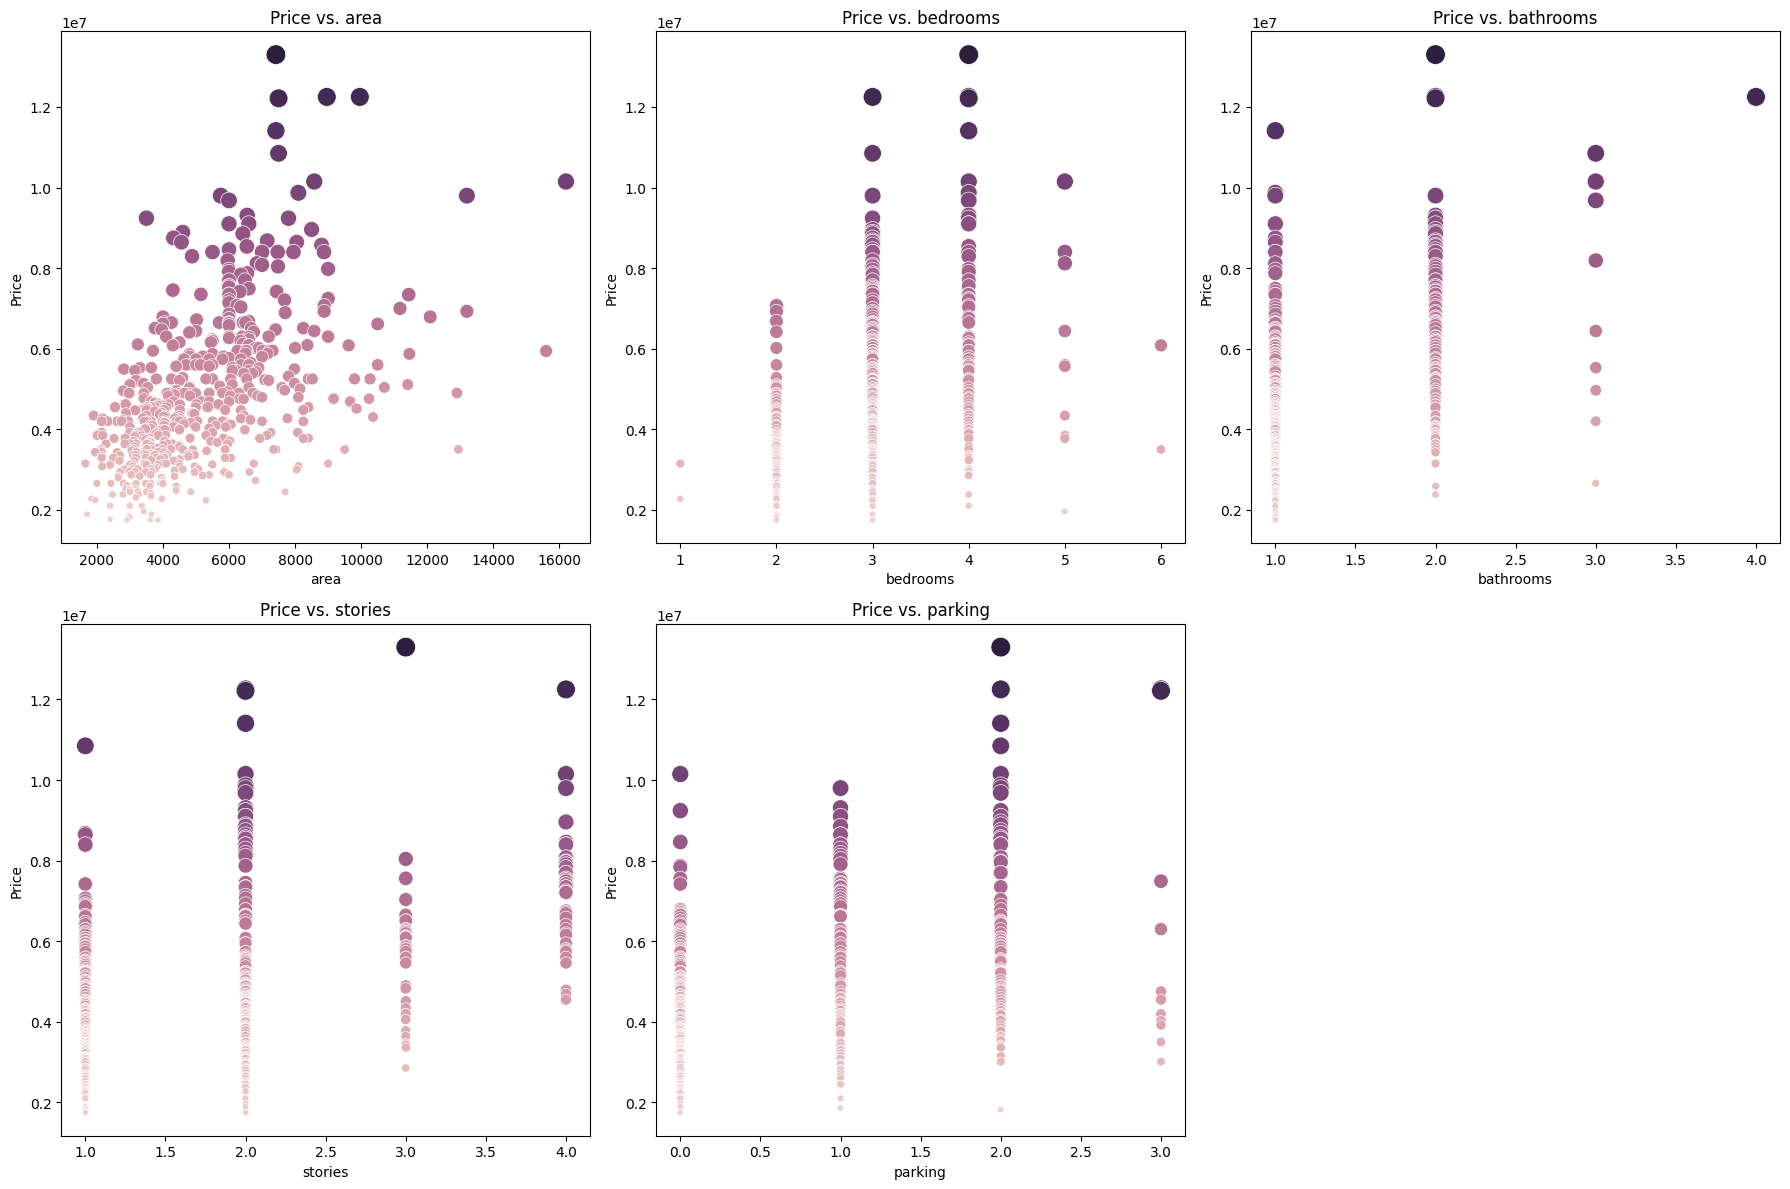

In [ ]:
plt.figure(figsize=(18, 12))
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=col, y='price', data=df, hue='price', size='price', sizes=(20, 200), legend=False)
    plt.title(f'Price vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

***Numerical vs. Categorical Features (Price vs. others)***

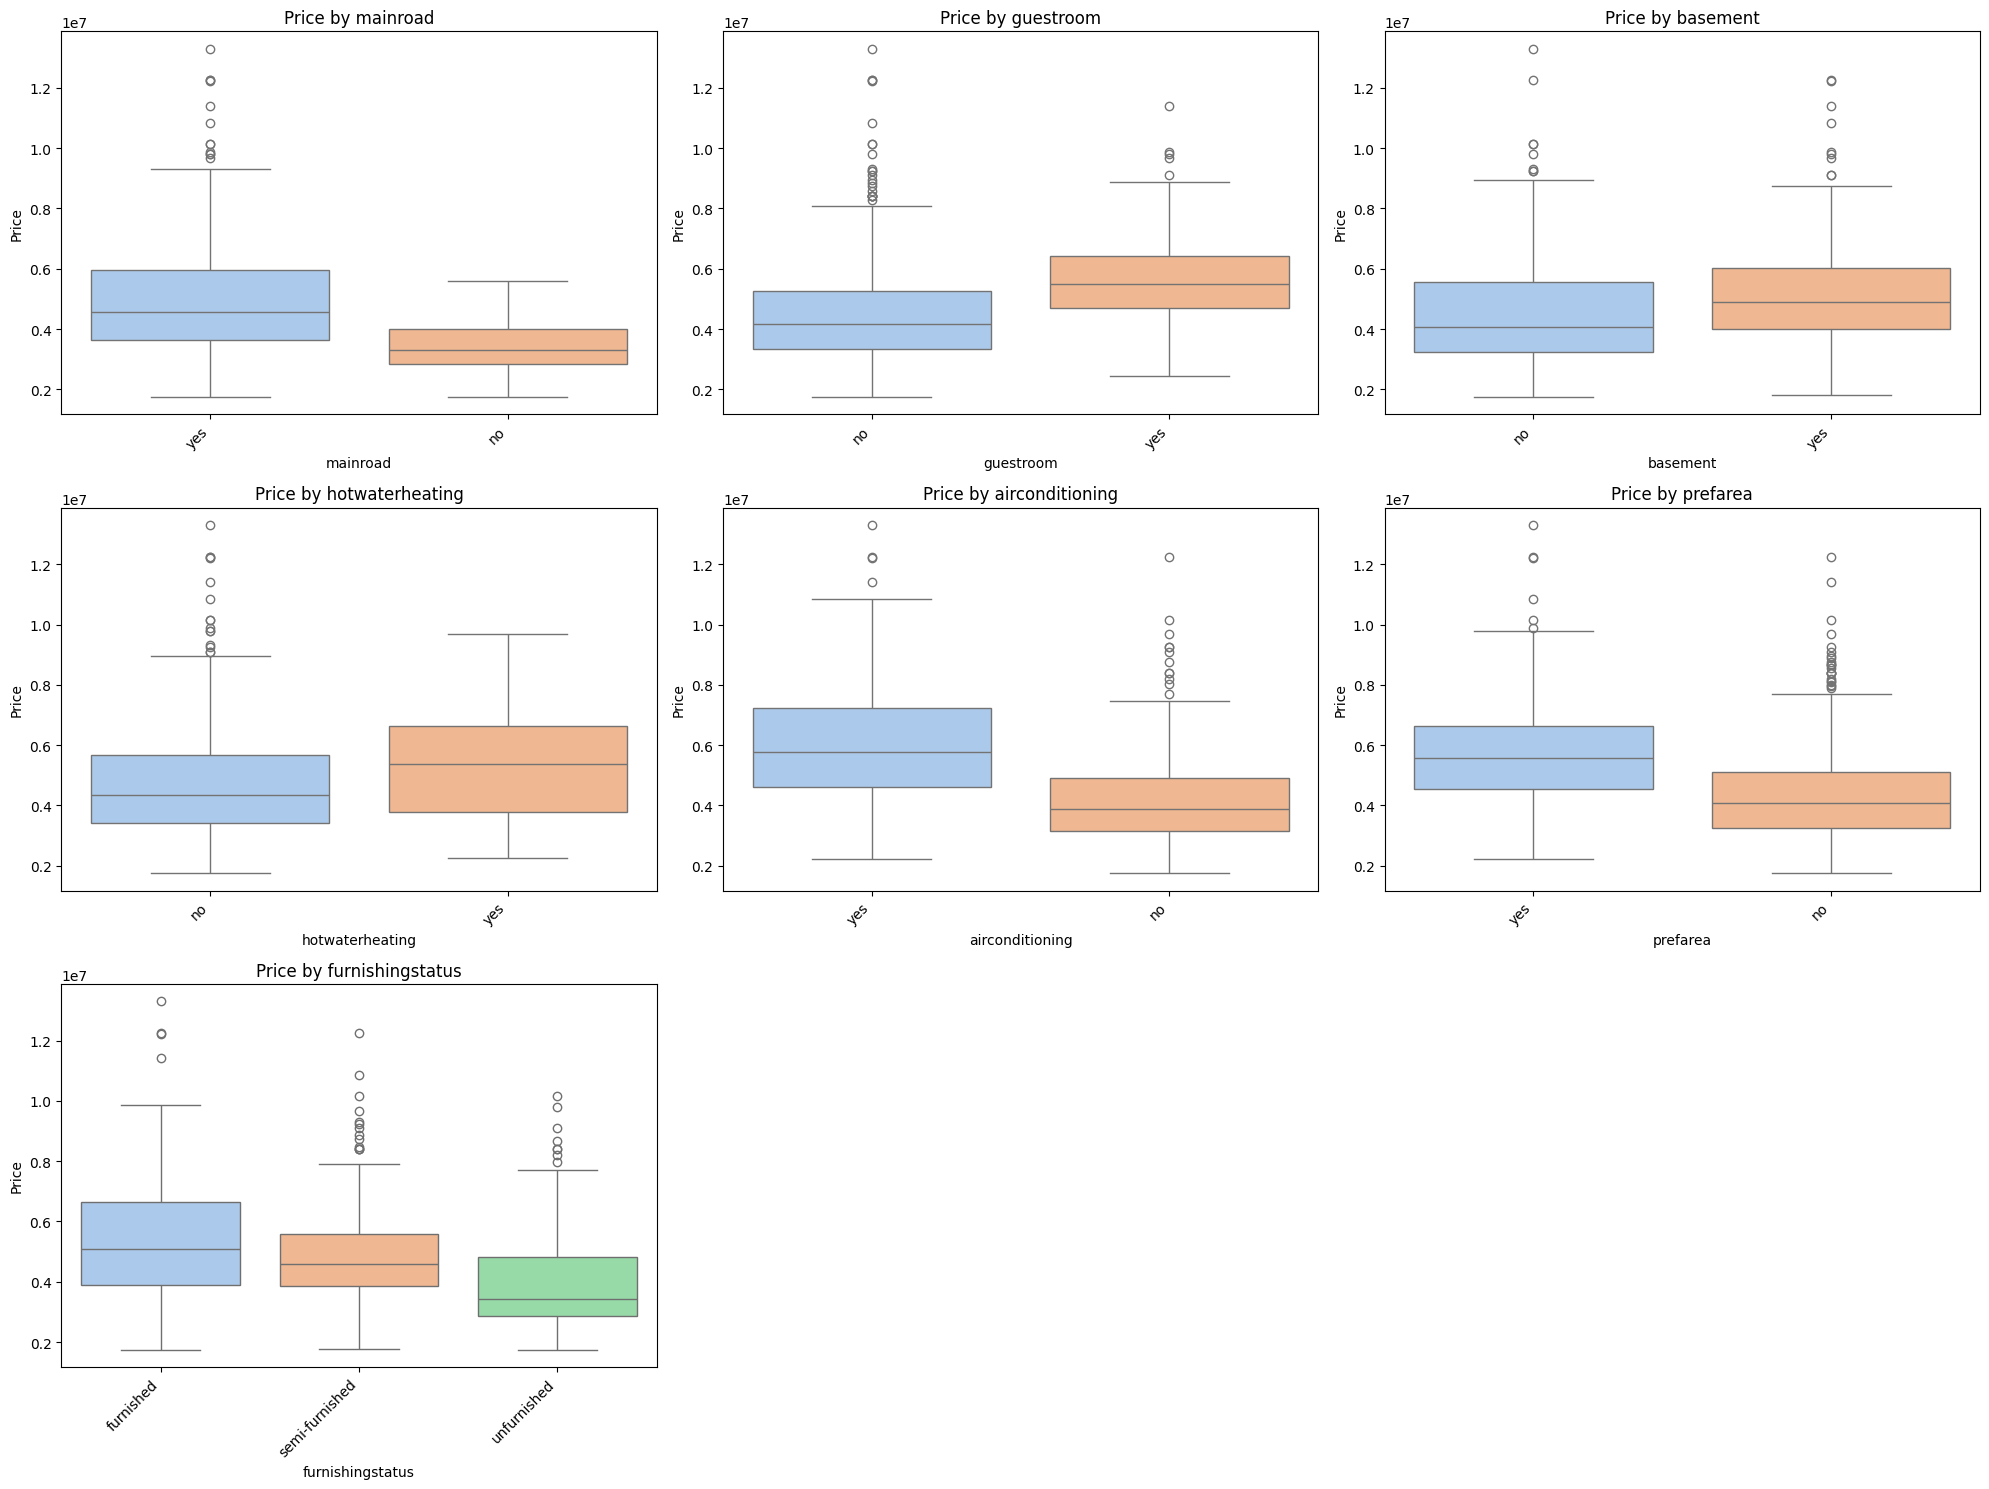

In [ ]:
plt.figure(figsize=(20, 15))
categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

for i, col in enumerate(categorical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=col, y='price', data=df, palette='pastel')
    plt.title(f'Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Multivariate Analysis (Correlation Matrix)

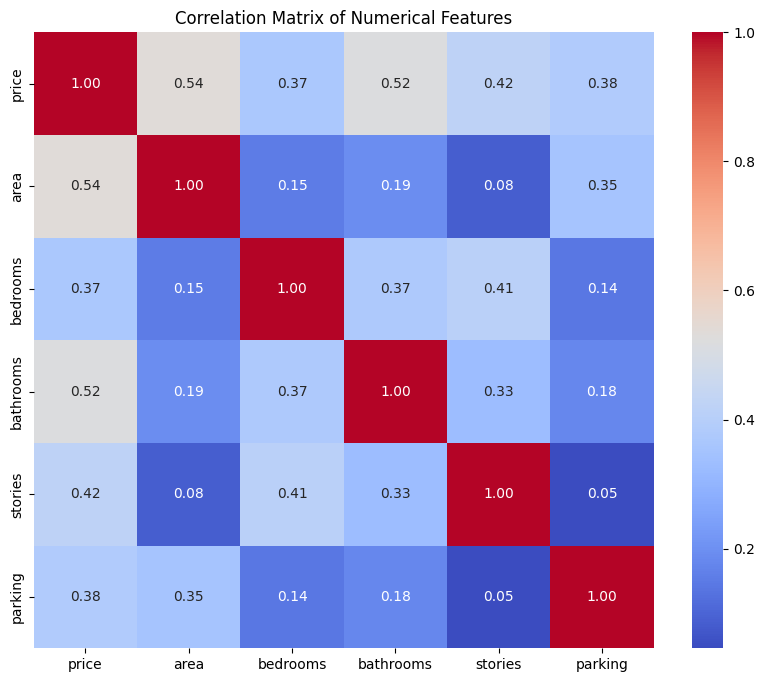

In [ ]:
numerical_cols_for_corr = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
correlation_matrix = df[numerical_cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [11]:
# ── 2. Preprocessing ──────────────────────────────────────────────────────────
# Encode binary yes/no columns -> 1/0
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Encode furnishingstatus as ordinal
df['furnishingstatus'] = df['furnishingstatus'].map(
    {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
)

# ── 3. Feature Engineering ────────────────────────────────────────────────────
df['area_per_bedroom'] = df['area'] / (df['bedrooms'] + 1)   # Space per room
df['bath_bed_ratio']   = df['bathrooms'] / (df['bedrooms'] + 1)
df['total_rooms']      = df['bedrooms'] + df['bathrooms']
df['luxury_score']     = (df['airconditioning'] + df['hotwaterheating']
                          + df['prefarea'] + df['furnishingstatus'])


In [12]:
# ── 4. Train / Test Split ─────────────────────────────────────────────────────
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [13]:

# ── 5. Model Comparison ───────────────────────────────────────────────────────
models = {
    'Random Forest': RandomForestRegressor(n_estimators=500, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    ),
}

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

results = {}
for name, mdl in models.items():
    mdl.fit(X_train_sc, y_train)
    preds = mdl.predict(X_test_sc)
    r2   = r2_score(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    cv   = cross_val_score(mdl, X_train_sc, y_train, cv=5, scoring='r2').mean()
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'CV_R2': cv}
    print(f"\n{name}:")
    print(f"  R2 Score : {r2:.4f}")
    print(f"  CV R2    : {cv:.4f}")
    print(f"  MAE      : {mae:,.0f}")
    print(f"  RMSE     : {rmse:,.0f}")


MODEL COMPARISON

Random Forest:
  R2 Score : 0.5989
  CV R2    : 0.5832
  MAE      : 1,047,886
  RMSE     : 1,423,946

Gradient Boosting:
  R2 Score : 0.6069
  CV R2    : 0.5461
  MAE      : 1,018,296
  RMSE     : 1,409,575

XGBoost:
  R2 Score : 0.6468
  CV R2    : 0.5600
  MAE      : 974,052
  RMSE     : 1,336,081


In [14]:
# ── 6. Stacking Ensemble ──────────────────────────────────────────────────────
estimators = [
    ('rf',  RandomForestRegressor(n_estimators=300, random_state=42)),
    ('gb',  GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=4, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                         random_state=42, verbosity=0)),
]
stack = StackingRegressor(estimators=estimators, final_estimator=Ridge(), cv=5)
stack.fit(X_train_sc, y_train)
stack_preds = stack.predict(X_test_sc)
stack_r2    = r2_score(y_test, stack_preds)
stack_cv    = cross_val_score(stack, X_train_sc, y_train, cv=5, scoring='r2').mean()
print(f"\nStacking Ensemble:")
print(f"  R2 Score : {stack_r2:.4f}")
print(f"  CV R2    : {stack_cv:.4f}")

# ── 7. Best Model (XGBoost) — Final Evaluation ───────────────────────────────
best = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
best.fit(X_train_sc, y_train)
best_preds = best.predict(X_test_sc)

r2   = r2_score(y_test, best_preds)
mae  = mean_absolute_error(y_test, best_preds)
rmse = np.sqrt(mean_squared_error(y_test, best_preds))
cv   = cross_val_score(best, X_train_sc, y_train, cv=5, scoring='r2')

print("\n" + "=" * 60)
print("BEST MODEL: XGBoost — Final Results")
print("=" * 60)
print(f"  R2 Score    : {r2:.4f}")
print(f"  CV R2 Mean  : {cv.mean():.4f} (+/- {cv.std():.4f})")
print(f"  MAE         : {mae:,.0f}")
print(f"  RMSE        : {rmse:,.0f}")


Stacking Ensemble:
  R2 Score : 0.6145
  CV R2    : 0.5931

BEST MODEL: XGBoost — Final Results
  R2 Score    : 0.6468
  CV R2 Mean  : 0.5600 (+/- 0.0409)
  MAE         : 974,052
  RMSE        : 1,336,081
